In [43]:
import gymnasium as gym

# Initialize the environment
env = gym.make("CartPole-v1", render_mode="human")

# Run 5 episodes
for episode in range(1, 6):
    state, info = env.reset()
    done = False
    truncated = False
    total_reward = 0
    
    while not (done or truncated):
        # Take a random action from the action space
        action = env.action_space.sample()
        state, reward, done, truncated, info = env.step(action)
        total_reward += reward
        
    print(f"Episode {episode}: Total Reward = {total_reward}")

env.close()

Episode 1: Total Reward = 13.0
Episode 2: Total Reward = 13.0
Episode 3: Total Reward = 51.0
Episode 4: Total Reward = 14.0
Episode 5: Total Reward = 17.0


In [45]:
import numpy as np
import random
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Add a transition to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Sample a batch of transitions."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones)
        )

    def __len__(self):
        return len(self.buffer)
    buffer = ReplayBuffer(100)
    buffer.push([0,0,0,0], 1, 1.0, [0,0,0,0], False)
    print(len(buffer))

1


In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        # We use ReLU as our activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
    model = QNetwork(4, 2)
    test_input = torch.tensor([0.1, 0.2, 0.3, 0.4], dtype=torch.float32)
    output = model(test_input)
    print(output)

tensor([ 0.0223, -0.0081], grad_fn=<ViewBackward0>)


In [47]:
import torch.optim as optim

# Hyperparameters
LR = 1e-3
BATCH_SIZE = 64
GAMMA = 0.99  # Discount factor for future rewards

# Initialize network and target network
policy_net = QNetwork(4, 2)
target_net = QNetwork(4, 2)
target_net.load_state_dict(policy_net.state_dict()) # Sync weights

# Optimizer
optimizer = optim.Adam(policy_net.parameters(), lr=LR)

In [48]:
def optimize_model(batch_size, memory, policy_net, target_net, optimizer):
    if len(memory) < batch_size:
        return

    # Sample from buffer
    states, actions, rewards, next_states, dones = memory.sample(batch_size)
    
    # Convert to tensors
    states = torch.tensor(states, dtype=torch.float32)
    actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32)
    dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

    # Calculate current Q values
    current_q = policy_net(states).gather(1, actions)

    # Calculate target Q values (Bellman equation)
    with torch.no_grad():
        max_next_q = target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * max_next_q * (1 - dones))

    # Loss and Optimization
    loss = F.mse_loss(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [49]:
import math

# Configuration
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000
STEPS_DONE = 0

def select_action(state, policy_net, env, steps_done):
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(torch.tensor(state, dtype=torch.float32)).argmax().item()
    else:
        return env.action_space.sample()

# Main Training Routine
env = gym.make("CartPole-v1")
memory = ReplayBuffer(10000)
num_episodes = 200

for i_episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    for t in range(500):
        action = select_action(state, policy_net, env, STEPS_DONE)
        STEPS_DONE += 1
        
        next_state, reward, done, truncated, _ = env.step(action)
        memory.push(state, action, reward, next_state, done or truncated)
        state = next_state
        
        optimize_model(BATCH_SIZE, memory, policy_net, target_net, optimizer)
        
        total_reward += reward
        if done or truncated:
            break
            
    # Soft update the target network
    if i_episode % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())
        print(f"Episode {i_episode}, Total Reward: {total_reward}")

env.close()

Episode 0, Total Reward: 20.0
Episode 10, Total Reward: 10.0
Episode 20, Total Reward: 16.0
Episode 30, Total Reward: 13.0
Episode 40, Total Reward: 26.0
Episode 50, Total Reward: 112.0
Episode 60, Total Reward: 177.0
Episode 70, Total Reward: 196.0
Episode 80, Total Reward: 208.0
Episode 90, Total Reward: 192.0
Episode 100, Total Reward: 202.0
Episode 110, Total Reward: 180.0
Episode 120, Total Reward: 166.0
Episode 130, Total Reward: 212.0
Episode 140, Total Reward: 200.0
Episode 150, Total Reward: 240.0
Episode 160, Total Reward: 270.0
Episode 170, Total Reward: 344.0
Episode 180, Total Reward: 191.0
Episode 190, Total Reward: 217.0


In [24]:
import torch
import torch.nn as nn
from torch.distributions import Categorical

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        # The Shared Feature Extractor
        self.fc = nn.Linear(state_dim, 64)
        
        # The Actor Head: Outputs action probabilities
        self.actor = nn.Linear(64, action_dim)
        
        # The Critic Head: Outputs a single scalar value V(s)
        self.critic = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.tanh(self.fc(x))
        
        # Actor: softmax to get probabilities
        action_probs = torch.softmax(self.actor(x), dim=-1)
        
        # Critic: linear output
        state_value = self.critic(x)
        
        return action_probs, state_value
    
    model = ActorCritic(4, 2)
    probs, val = model(torch.randn(4))
    print(probs)
    print(val)

tensor([0.4034, 0.5966], grad_fn=<SoftmaxBackward0>)
tensor([0.0162], grad_fn=<ViewBackward0>)


In [25]:
class RolloutBuffer:
    def __init__(self):
        self.actions = []
        self.states = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
    
    def clear(self):
        del self.actions[:]
        del self.states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.is_terminals[:]

# Helper to act according to the current policy
def get_action(state, model):
    state = torch.tensor(state, dtype=torch.float32)
    action_probs, _ = model(state)
    dist = Categorical(action_probs)
    action = dist.sample()
    return action.item(), dist.log_prob(action)
buffer = RolloutBuffer()
# Ensure this is 4 for CartPole-v1
model = ActorCritic(state_dim=4, action_dim=2)
action, log_prob = get_action([0.1, 0.2, 0.3, 0.4], model)
print(action, log_prob)


1 tensor(-0.5459, grad_fn=<SqueezeBackward1>)


In [32]:
def ppo_loss(new_probs, old_probs, advantages, entropy_beta=0.01, clip_param=0.2):
    # Ratio
    ratio = torch.exp(new_probs - old_probs)
    
    # Clipped objective
    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1.0 - clip_param, 1.0 + clip_param) * advantages
    
    # Entropy bonus (to encourage exploration)
    # new_probs here should be the distribution itself to calculate entropy
    # Assuming dist is passed or recalculated
    # For simplicity, if you can't access dist, you can omit the entropy_beta term for now
    
    return -torch.min(surr1, surr2).mean()

In [33]:
# Setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
buffer = RolloutBuffer()

# Training loop
for episode in range(100):
    state, _ = env.reset()
    buffer.clear()
    
    # 1. Collect Trajectories (Rollout)
    for t in range(200):
        action, log_prob = get_action(state, model)
        next_state, reward, done, truncated, _ = env.step(action)
        
        buffer.states.append(state)
        buffer.actions.append(action)
        buffer.logprobs.append(log_prob)
        buffer.rewards.append(reward)
        
        state = next_state
        if done or truncated: break
            
    # 2. Optimize (PPO Update)
    # Convert lists to tensors
    old_states = torch.tensor(np.array(buffer.states), dtype=torch.float32)
    old_actions = torch.tensor(buffer.actions, dtype=torch.long)
    old_logprobs = torch.stack(buffer.logprobs).detach()
    
    # Calculate returns (simple cumulative reward here)
    returns = torch.tensor(buffer.rewards, dtype=torch.float32) 
    
    # Update loop
    new_probs, values = model(old_states)
    dist = Categorical(new_probs)
    new_logprobs = dist.log_prob(old_actions)
    
    # Advantages (for simplicity, we use returns - values)
    advantages = returns - values.detach().squeeze()
    
    loss = ppo_loss(new_logprobs, old_logprobs, advantages)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Episode {episode} completed. Loss: {loss.item():.4f}")
    episode_reward = sum(buffer.rewards)
print(f"Episode {episode}, Reward: {episode_reward}, Loss: {loss.item():.4f}")

Episode 0 completed. Loss: -0.9644
Episode 1 completed. Loss: -0.9787
Episode 2 completed. Loss: -0.9745
Episode 3 completed. Loss: -0.9650
Episode 4 completed. Loss: -0.9729
Episode 5 completed. Loss: -0.9857
Episode 6 completed. Loss: -0.9629
Episode 7 completed. Loss: -0.9819
Episode 8 completed. Loss: -0.9758
Episode 9 completed. Loss: -0.9894
Episode 10 completed. Loss: -0.9902
Episode 11 completed. Loss: -0.9863
Episode 12 completed. Loss: -0.9682
Episode 13 completed. Loss: -0.9883
Episode 14 completed. Loss: -0.9960
Episode 15 completed. Loss: -0.9875
Episode 16 completed. Loss: -0.9672
Episode 17 completed. Loss: -0.9722
Episode 18 completed. Loss: -0.9642
Episode 19 completed. Loss: -0.9794
Episode 20 completed. Loss: -1.0008
Episode 21 completed. Loss: -0.9814
Episode 22 completed. Loss: -0.9643
Episode 23 completed. Loss: -0.9789
Episode 24 completed. Loss: -0.9706
Episode 25 completed. Loss: -0.9818
Episode 26 completed. Loss: -0.9894
Episode 27 completed. Loss: -0.9944
Ep

In [38]:
# Ensure these imports are at the top
import numpy as np
from torch.distributions import Categorical

# 1. Advantage Normalization and PPO Update logic
def update_ppo(model, optimizer, buffer, ppo_loss_func):
    # 1. Convert to tensors
    old_states = torch.tensor(np.array(buffer.states), dtype=torch.float32)
    old_actions = torch.tensor(buffer.actions, dtype=torch.long)
    old_logprobs = torch.stack(buffer.logprobs).detach()
    
    # 2. Compute Returns (Crucial: Use discount factor GAMMA=0.99 for stability)
    returns = []
    discounted_sum = 0
    for r in reversed(buffer.rewards):
        discounted_sum = r + 0.99 * discounted_sum
        returns.insert(0, discounted_sum)
    returns = torch.tensor(returns, dtype=torch.float32)
    
    # 3. Training Loop
    for _ in range(10): # Increase epochs for better learning
        new_probs, values = model(old_states)
        dist = Categorical(new_probs)
        new_logprobs = dist.log_prob(old_actions)
        
        # Normalize returns (not just advantages) to keep scale consistent
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        advantages = returns - values.squeeze().detach()
        
        # Policy Loss
        policy_loss = ppo_loss_func(new_logprobs, old_logprobs, advantages)
        
        # Critic Loss
        value_loss = F.mse_loss(values.squeeze(), returns)
        
        total_loss = policy_loss + 0.5 * value_loss
        
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

# 2. Updated Main Training Loop
for episode in range(300):
    state, _ = env.reset()
    buffer.clear()
    total_reward = 0
    
    for t in range(500):
        action, log_prob = get_action(state, model)
        next_state, reward, done, truncated, _ = env.step(action)
        
        buffer.states.append(state)
        buffer.actions.append(action)
        buffer.logprobs.append(log_prob)
        buffer.rewards.append(reward)
        
        state = next_state
        total_reward += reward
        if done or truncated: break
            
    update_ppo(model, optimizer, buffer, ppo_loss)
    print(f"{total_reward}, ")

104.0, 
174.0, 
199.0, 
178.0, 
153.0, 
247.0, 
177.0, 
236.0, 
147.0, 
111.0, 
153.0, 
138.0, 
136.0, 
172.0, 
159.0, 
128.0, 
164.0, 
202.0, 
211.0, 
135.0, 
129.0, 
178.0, 
286.0, 
155.0, 
341.0, 
379.0, 
155.0, 
180.0, 
267.0, 
239.0, 
368.0, 
432.0, 
234.0, 
331.0, 
284.0, 
203.0, 
167.0, 
281.0, 
206.0, 
212.0, 
223.0, 
225.0, 
289.0, 
198.0, 
167.0, 
209.0, 
244.0, 
143.0, 
239.0, 
203.0, 
161.0, 
212.0, 
157.0, 
224.0, 
365.0, 
419.0, 
218.0, 
222.0, 
400.0, 
217.0, 
183.0, 
167.0, 
376.0, 
409.0, 
302.0, 
278.0, 
481.0, 
291.0, 
500.0, 
362.0, 
500.0, 
467.0, 
236.0, 
248.0, 
500.0, 
363.0, 
390.0, 
481.0, 
355.0, 
186.0, 
249.0, 
313.0, 
469.0, 
500.0, 
500.0, 
500.0, 
395.0, 
270.0, 
358.0, 
481.0, 
500.0, 
500.0, 
283.0, 
500.0, 
441.0, 
304.0, 
271.0, 
324.0, 
388.0, 
364.0, 
500.0, 
445.0, 
500.0, 
82.0, 
431.0, 
402.0, 
228.0, 
261.0, 
500.0, 
384.0, 
272.0, 
500.0, 
500.0, 
500.0, 
500.0, 
318.0, 
500.0, 
202.0, 
367.0, 
418.0, 
500.0, 
500.0, 
500.0, 
303.0, 
500.0, 
5

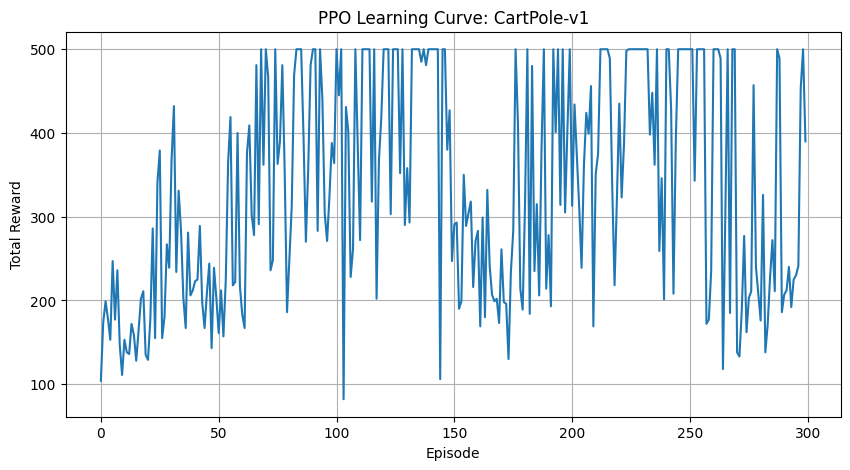

In [41]:
import matplotlib.pyplot as plt

# Replace 'rewards' with your actual list of rewards from the PPO run
reward_history = [104.0, 
174.0, 
199.0, 
178.0, 
153.0, 
247.0, 
177.0, 
236.0, 
147.0, 
111.0, 
153.0, 
138.0, 
136.0, 
172.0, 
159.0, 
128.0, 
164.0, 
202.0, 
211.0, 
135.0, 
129.0, 
178.0, 
286.0, 
155.0, 
341.0, 
379.0, 
155.0, 
180.0, 
267.0, 
239.0, 
368.0, 
432.0, 
234.0, 
331.0, 
284.0, 
203.0, 
167.0, 
281.0, 
206.0, 
212.0, 
223.0, 
225.0, 
289.0, 
198.0, 
167.0, 
209.0, 
244.0, 
143.0, 
239.0, 
203.0, 
161.0, 
212.0, 
157.0, 
224.0, 
365.0, 
419.0, 
218.0, 
222.0, 
400.0, 
217.0, 
183.0, 
167.0, 
376.0, 
409.0, 
302.0, 
278.0, 
481.0, 
291.0, 
500.0, 
362.0, 
500.0, 
467.0, 
236.0, 
248.0, 
500.0, 
363.0, 
390.0, 
481.0, 
355.0, 
186.0, 
249.0, 
313.0, 
469.0, 
500.0, 
500.0, 
500.0, 
395.0, 
270.0, 
358.0, 
481.0, 
500.0, 
500.0, 
283.0, 
500.0, 
441.0, 
304.0, 
271.0, 
324.0, 
388.0, 
364.0, 
500.0, 
445.0, 
500.0, 
82.0, 
431.0, 
402.0, 
228.0, 
261.0, 
500.0, 
384.0, 
272.0, 
500.0, 
500.0, 
500.0, 
500.0, 
318.0, 
500.0, 
202.0, 
367.0, 
418.0, 
500.0, 
500.0, 
500.0, 
303.0, 
500.0, 
500.0, 
500.0, 
352.0, 
500.0, 
290.0, 
358.0, 
293.0, 
500.0, 
500.0, 
500.0, 
500.0, 
485.0, 
500.0, 
481.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
106.0, 
500.0, 
500.0, 
380.0, 
427.0, 
247.0, 
291.0, 
293.0, 
190.0, 
199.0, 
350.0, 
289.0, 
304.0, 
318.0, 
216.0, 
271.0, 
283.0, 
169.0, 
299.0, 
180.0, 
332.0, 
241.0, 
207.0, 
199.0, 
202.0, 
173.0, 
261.0, 
198.0, 
196.0, 
130.0, 
234.0, 
283.0, 
500.0, 
412.0, 
214.0, 
189.0, 
315.0, 
500.0, 
184.0, 
480.0, 
235.0, 
315.0, 
206.0, 
381.0, 
500.0, 
214.0, 
278.0, 
193.0, 
500.0, 
401.0, 
500.0, 
314.0, 
500.0, 
305.0, 
405.0, 
500.0, 
313.0, 
434.0, 
373.0, 
311.0, 
239.0, 
361.0, 
424.0, 
399.0, 
456.0, 
169.0, 
351.0, 
375.0, 
500.0, 
500.0, 
500.0, 
500.0, 
489.0, 
337.0, 
218.0, 
322.0, 
435.0, 
323.0, 
386.0, 
498.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
398.0, 
448.0, 
362.0, 
500.0, 
259.0, 
346.0, 
201.0, 
500.0, 
500.0, 
429.0, 
208.0, 
392.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
500.0, 
343.0, 
500.0, 
500.0, 
500.0, 
500.0, 
172.0, 
177.0, 
235.0, 
500.0, 
500.0, 
500.0, 
489.0, 
118.0, 
301.0, 
500.0, 
185.0, 
500.0, 
500.0, 
138.0, 
133.0, 
189.0, 
277.0, 
162.0, 
203.0, 
211.0, 
457.0, 
240.0, 
208.0, 
176.0, 
326.0, 
138.0, 
172.0, 
228.0, 
272.0, 
211.0, 
500.0, 
489.0, 
186.0, 
207.0, 
212.0, 
240.0, 
192.0, 
225.0, 
230.0, 
241.0, 
453.0, 
500.0, 
390.0,] 

plt.figure(figsize=(10, 5))
plt.plot(rewards, label='PPO Reward')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('PPO Learning Curve: CartPole-v1')
plt.grid(True)
plt.savefig('learning_curve.png')
plt.show()

In [40]:
# Save the model weights
torch.save(model.state_dict(), "ppo_cartpole.pth")
print("Model weights saved successfully.")

# To load it later for inference:
# model = ActorCritic(state_dim=4, action_dim=2)
# model.load_state_dict(torch.load("ppo_cartpole.pth"))
# model.eval()

Model weights saved successfully.


In [42]:
import numpy as np

# Assuming 'reward_history' is your list of rewards, e.g., [13.0, 10.0, ...]
# Convert to numpy array for easier calculation
rewards = np.array(reward_history)

# 1. Episodes to reach reward 200
# np.where returns indices where the condition is true; [0][0] gets the first one
episodes_to_200 = np.where(rewards >= 200)[0][0] if np.any(rewards >= 200) else "Not reached"

# 2. Best reward
best_reward = np.max(rewards)

# 3. Average reward over last 100 episodes
avg_reward_last_100 = np.mean(rewards[-100:])

# 4. Print metrics
print(f"Episodes to reach reward 200: {episodes_to_200}")
print(f"Best reward achieved: {best_reward}")
print(f"Average reward (last 100 episodes): {avg_reward_last_100:.2f}")

Episodes to reach reward 200: 5
Best reward achieved: 500.0
Average reward (last 100 episodes): 365.82


In [6]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

env = gym.make("LunarLander-v3")
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
env.close()

In [7]:
from torch.distributions import Categorical

# PPO Hyperparameters - cleaner defaults
PPO_EPISODES    = 2500
GAMMA           = 0.99
GAE_LAMBDA      = 0.95
CLIP_EPS        = 0.2
PPO_LR          = 2.5e-4
PPO_EPOCHS      = 10
ROLLOUT_STEPS   = 1024
MINI_BATCH      = 256
VF_COEF         = 0.5
ENT_COEF        = 0.01
MAX_GRAD_NORM   = 0.5

class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        # separate networks for actor and critic - more stable than shared
        self.actor_net = nn.Sequential(
            nn.Linear(obs_dim, 64), nn.Tanh(),
            nn.Linear(64, 64),      nn.Tanh(),
            nn.Linear(64, act_dim)
        )
        self.critic_net = nn.Sequential(
            nn.Linear(obs_dim, 64), nn.Tanh(),
            nn.Linear(64, 64),      nn.Tanh(),
            nn.Linear(64, 1)
        )

    def get_action(self, obs):
        logits = self.actor_net(obs)
        value  = self.critic_net(obs).squeeze(-1)
        dist   = Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value

    def evaluate(self, obs, actions):
        logits = self.actor_net(obs)
        value  = self.critic_net(obs).squeeze(-1)
        dist   = Categorical(logits=logits)
        return dist.log_prob(actions), dist.entropy(), value

def compute_gae(rewards, values, dones, last_value):
    advantages = []
    gae = 0
    values = values + [last_value]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + GAMMA * values[t+1] * (1 - dones[t]) - values[t]
        gae   = delta + GAMMA * GAE_LAMBDA * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    returns = [adv + val for adv, val in zip(advantages, values[:-1])]
    return advantages, returns

env_ppo       = gym.make("LunarLander-v3")
model         = ActorCritic(obs_dim, act_dim)
optimizer_ppo = optim.Adam(model.parameters(), lr=PPO_LR, eps=1e-5)

ppo_rewards = []
ep_reward   = 0
ep_count    = 0
best_mean   = -np.inf
obs, _      = env_ppo.reset()

obs_buf, act_buf, logp_buf = [], [], []
rew_buf, val_buf, don_buf  = [], [], []
step = 0

while ep_count < PPO_EPISODES:
    obs_t = torch.FloatTensor(obs)
    with torch.no_grad():
        action, logp, _, value = model.get_action(obs_t)

    next_obs, reward, terminated, truncated, _ = env_ppo.step(action.item())
    done = terminated or truncated

    obs_buf.append(obs)
    act_buf.append(action.item())
    logp_buf.append(logp.item())
    rew_buf.append(reward)
    val_buf.append(value.item())
    don_buf.append(float(done))

    ep_reward += reward
    obs = next_obs
    step += 1

    if done:
        ppo_rewards.append(ep_reward)
        ep_count += 1
        ep_reward = 0
        obs, _ = env_ppo.reset()

        if ep_count % 100 == 0:
            mean100 = np.mean(ppo_rewards[-100:])
            if mean100 > best_mean:
                best_mean = mean100
            print(f"[PPO] Ep {ep_count:4d} | Mean(100): {mean100:7.1f} | Best: {best_mean:7.1f}")

    if step % ROLLOUT_STEPS == 0 and len(obs_buf) > 0:
        with torch.no_grad():
            _, _, _, last_val = model.get_action(torch.FloatTensor(obs))

        advantages, returns = compute_gae(rew_buf, val_buf, don_buf, last_val.item())

        adv_t  = torch.FloatTensor(advantages)
        adv_t  = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)
        obs_t  = torch.FloatTensor(np.array(obs_buf))
        act_t  = torch.LongTensor(act_buf)
        logp_t = torch.FloatTensor(logp_buf)
        ret_t  = torch.FloatTensor(returns)

        n = len(obs_buf)
        for _ in range(PPO_EPOCHS):
            indices = np.random.permutation(n)
            for start in range(0, n, MINI_BATCH):
                idx = indices[start:start+MINI_BATCH]
                new_logp, entropy, new_val = model.evaluate(obs_t[idx], act_t[idx])

                ratio       = (new_logp - logp_t[idx]).exp()
                surr1       = ratio * adv_t[idx]
                surr2       = torch.clamp(ratio, 1-CLIP_EPS, 1+CLIP_EPS) * adv_t[idx]
                actor_loss  = -torch.min(surr1, surr2).mean()
                critic_loss = nn.MSELoss()(new_val, ret_t[idx])
                ent_loss    = -entropy.mean()

                loss = actor_loss + VF_COEF * critic_loss + ENT_COEF * ent_loss
                optimizer_ppo.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer_ppo.step()

        obs_buf, act_buf, logp_buf = [], [], []
        rew_buf, val_buf, don_buf  = [], [], []

env_ppo.close()
ppo_best = np.mean(ppo_rewards[-100:])
print(f"\nPPO done. Final Mean(100): {ppo_best:.1f} | Best Mean(100): {best_mean:.1f}")

[PPO] Ep  100 | Mean(100):  -156.1 | Best:  -156.1
[PPO] Ep  200 | Mean(100):  -147.7 | Best:  -147.7
[PPO] Ep  300 | Mean(100):   -94.2 | Best:   -94.2
[PPO] Ep  400 | Mean(100):   -39.2 | Best:   -39.2
[PPO] Ep  500 | Mean(100):     4.3 | Best:     4.3
[PPO] Ep  600 | Mean(100):    30.4 | Best:    30.4
[PPO] Ep  700 | Mean(100):    41.1 | Best:    41.1
[PPO] Ep  800 | Mean(100):    60.4 | Best:    60.4
[PPO] Ep  900 | Mean(100):    67.9 | Best:    67.9
[PPO] Ep 1000 | Mean(100):   114.0 | Best:   114.0
[PPO] Ep 1100 | Mean(100):   126.6 | Best:   126.6
[PPO] Ep 1200 | Mean(100):   146.8 | Best:   146.8
[PPO] Ep 1300 | Mean(100):    86.0 | Best:   146.8
[PPO] Ep 1400 | Mean(100):    96.2 | Best:   146.8
[PPO] Ep 1500 | Mean(100):   107.4 | Best:   146.8
[PPO] Ep 1600 | Mean(100):    88.5 | Best:   146.8
[PPO] Ep 1700 | Mean(100):   108.6 | Best:   146.8
[PPO] Ep 1800 | Mean(100):   128.6 | Best:   146.8
[PPO] Ep 1900 | Mean(100):   111.9 | Best:   146.8
[PPO] Ep 2000 | Mean(100):   13

In [ ]:
# DQN Hyperparameters
EPISODES      = 1000
GAMMA         = 0.99
LR            = 1e-3
BATCH_SIZE    = 64
BUFFER_SIZE   = 50_000
EPS_START     = 1.0
EPS_END       = 0.01
EPS_DECAY     = 0.995
TARGET_UPDATE = 10

class QNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),     nn.ReLU(),
            nn.Linear(128, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, s_, done):
        self.buf.append((s, a, r, s_, done))
    def sample(self, n):
        batch = random.sample(self.buf, n)
        s, a, r, s_, d = zip(*batch)
        return (torch.FloatTensor(np.array(s)),
                torch.LongTensor(a),
                torch.FloatTensor(r),
                torch.FloatTensor(np.array(s_)),
                torch.FloatTensor(d))
    def __len__(self):
        return len(self.buf)

env_dqn    = gym.make("LunarLander-v3")
online_net = QNetwork(obs_dim, act_dim)
target_net = QNetwork(obs_dim, act_dim)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

optimizer  = optim.Adam(online_net.parameters(), lr=LR)
buffer     = ReplayBuffer(BUFFER_SIZE)
epsilon    = EPS_START
dqn_rewards = []
dqn_best   = -np.inf

for ep in range(1, EPISODES + 1):
    obs, _ = env_dqn.reset()
    ep_reward = 0
    done = False

    while not done:
        if random.random() < epsilon:
            action = env_dqn.action_space.sample()
        else:
            with torch.no_grad():
                action = online_net(torch.FloatTensor(obs)).argmax().item()

        next_obs, reward, terminated, truncated, _ = env_dqn.step(action)
        done = terminated or truncated
        buffer.push(obs, action, reward, next_obs, float(done))
        obs = next_obs
        ep_reward += reward

        if len(buffer) >= BATCH_SIZE:
            s, a, r, s_, d = buffer.sample(BATCH_SIZE)
            with torch.no_grad():
                target = r + GAMMA * target_net(s_).max(1)[0] * (1 - d)
            current = online_net(s).gather(1, a.unsqueeze(1)).squeeze()
            loss = nn.MSELoss()(current, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    dqn_rewards.append(ep_reward)

    if ep % TARGET_UPDATE == 0:
        target_net.load_state_dict(online_net.state_dict())

    if ep % 100 == 0:
        mean100 = np.mean(dqn_rewards[-100:])
        if mean100 > dqn_best:
            dqn_best = mean100
        print(f"[DQN] Ep {ep:4d} | Mean(100): {mean100:7.1f} | Best: {dqn_best:7.1f}")

env_dqn.close()
print(f"\nDQN done. Final Mean(100): {np.mean(dqn_rewards[-100:]):.1f} | Best Mean(100): {dqn_best:.1f}")

[DQN] Ep  100 | Mean(100):  -126.3 | Best:  -126.3
[DQN] Ep  200 | Mean(100):   -62.3 | Best:   -62.3


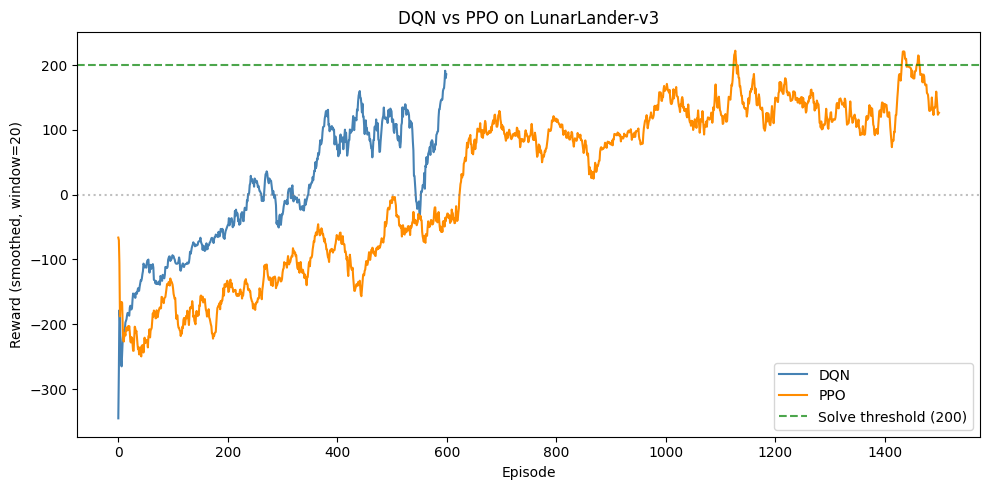

Saved reward_curve.png


In [5]:
import matplotlib.pyplot as plt

def smooth(rewards, window=20):
    return [np.mean(rewards[max(0,i-window):i+1]) for i in range(len(rewards))]

plt.figure(figsize=(10, 5))
plt.plot(smooth(dqn_rewards), label='DQN', color='steelblue')
plt.plot(smooth(ppo_rewards), label='PPO', color='darkorange')
plt.axhline(y=200, color='green', linestyle='--', alpha=0.7, label='Solve threshold (200)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Episode')
plt.ylabel('Reward (smoothed, window=20)')
plt.title('DQN vs PPO on LunarLander-v3')
plt.legend()
plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150)
plt.show()
print("Saved reward_curve.png")